## Numbers Dataset

We have a dataset of handwritten digits from 0 to 9

We need some library to read the images, I've chosen the pillow library which comes with Anaconda, if you need to 

pip install Pillow

should install it for you

In [1]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
from PIL import Image

## 1. Preparing the Data

In [2]:
# Printing Examples
def printexamples(X, y, examples_per_class = 10, number_of_classes = 10, mult = 1.0):
    pos = 0
    data = pd.DataFrame(y, columns=["yvalue"])
    for cls in range(number_of_classes):
        this_class = data[data["yvalue"] == cls]
        idxs = this_class.sample(examples_per_class).index
        for i, idx in enumerate(idxs):
            plt.subplot(examples_per_class, number_of_classes, i * number_of_classes + cls + 1)
            plt.imshow((X[idx]*mult).reshape(20,20).astype('uint8'), cmap='gray')
            plt.axis('off')
            if i == 0:
                plt.title(str(cls))
    plt.show()

In [3]:
# Load the image files
filelist = glob.glob('data/*/*.png')


X = np.array([np.array(Image.open(fname)).flatten() for fname in filelist])


# Create target from filenames (use '\\' on windows)
y = np.array([int(fname.split('\\')[-2]) for fname in filelist])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y sample: {y[:20]}")


X shape: (5000, 400)
y shape: (5000,)
y sample: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [4]:
# Check pixel value ranges
print(f"Min pixel value: {X.min()}")
print(f"Max pixel value: {X.max()}")

Min pixel value: 0
Max pixel value: 255


In [5]:
X = X.reshape(5000,400)

In [6]:
# Scale data [0, 1]
X = X / 255.0

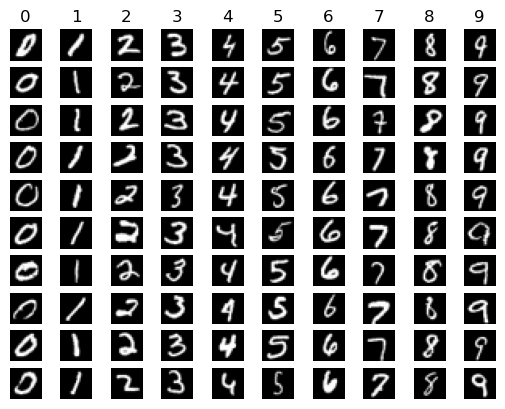

In [7]:
# Print examples
printexamples(X, y, mult=255.0)

In [8]:
# Split into train/validation/test (60/20/20)
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=1138, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=1138, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Temp: {X_temp.shape}, Test: {X_test.shape}")

Train: (3000, 400), Val: (1000, 400), Temp: (4000, 400), Test: (1000, 400)


## 2. Linear Support Vector Machine

In [9]:
# Section 2: Linear Support Vector Machine
from sklearn.svm import SVC

In [10]:
SVC?

Init signature:
SVC(
    *,
    C=1.0,
    kernel='rbf',
    degree=3,
    gamma='scale',
    coef0=0.0,
    shrinking=True,
    probability=False,
    tol=0.001,
    cache_size=200,
    class_weight=None,
    verbose=False,
    max_iter=-1,
    decision_function_shape='ovr',
    break_ties=False,
    random_state=None,
)
Docstring:     
C-Support Vector Classification.

The implementation is based on libsvm. The fit time scales at least
quadratically with the number of samples and may be impractical
beyond tens of thousands of samples. For large datasets
consider using :class:`~sklearn.svm.LinearSVC` or
:class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
:class:`~sklearn.kernel_approximation.Nystroem` transformer or
other :ref:`kernel_approximation`.

The multiclass support is handled according to a one-vs-one scheme.

For details on the precise mathematical formulation of the provided
kernel functions and how `gamma`, `coef0` and `degree` affect each
other, see the

In [11]:
# Train linear SVM
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [12]:
print("Linear SVM trained successfully")

Linear SVM trained successfully


In [13]:
# Calculate training and validation accuracy
train_acc = svm_linear.score(X_train, y_train)
val_acc = svm_linear.score(X_val, y_val)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Difference: {(train_acc - val_acc):.4f}")

Train accuracy: 0.9980
Validation Accuracy: 0.9260
Difference: 0.0720


Moderate overfitting is present

In [14]:
from sklearn.metrics import confusion_matrix, classification_report

In [15]:
confusion_matrix?

Signature:
confusion_matrix(
    y_true,
    y_pred,
    *,
    labels=None,
    sample_weight=None,
    normalize=None,
)
Docstring:
Compute confusion matrix to evaluate the accuracy of a classification.

By definition a confusion matrix :math:`C` is such that :math:`C_{i, j}`
is equal to the number of observations known to be in group :math:`i` and
predicted to be in group :math:`j`.

Thus in binary classification, the count of true negatives is
:math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, true positives is
:math:`C_{1,1}` and false positives is :math:`C_{0,1}`.

Read more in the :ref:`User Guide <confusion_matrix>`.

Parameters
----------
y_true : array-like of shape (n_samples,)
    Ground truth (correct) target values.

y_pred : array-like of shape (n_samples,)
    Estimated targets as returned by a classifier.

labels : array-like of shape (n_classes,), default=None
    List of labels to index the matrix. This may be used to reorder
    or select a subset of labels.
    I

In [16]:
classification_report?

Signature:
classification_report(
    y_true,
    y_pred,
    *,
    labels=None,
    target_names=None,
    sample_weight=None,
    digits=2,
    output_dict=False,
    zero_division='warn',
)
Docstring:
Build a text report showing the main classification metrics.

Read more in the :ref:`User Guide <classification_report>`.

Parameters
----------
y_true : 1d array-like, or label indicator array / sparse matrix
    Ground truth (correct) target values. Sparse matrix is only supported when
    targets are of :term:`multilabel` type.

y_pred : 1d array-like, or label indicator array / sparse matrix
    Estimated targets as returned by a classifier. Sparse matrix is only
    supported when targets are of :term:`multilabel` type.

labels : array-like of shape (n_labels,), default=None
    Optional list of label indices to include in the report.

target_names : array-like of shape (n_labels,), default=None
    Optional display names matching the labels (same order).

sample_weight : array-l

In [17]:
# Confusion matrix and classification report on validation set
y_val_pred = svm_linear.predict(X_val)

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
print("Confusion Matrix:")
print(cm)
print()

Confusion Matrix:
[[ 97   0   1   0   0   0   1   0   1   0]
 [  0 100   0   0   0   0   0   0   0   0]
 [  0   1  93   1   1   0   1   1   2   0]
 [  0   0   0  90   0   5   0   1   2   2]
 [  0   0   1   0  95   0   1   1   0   2]
 [  1   2   2   4   3  85   1   0   2   0]
 [  1   0   0   0   1   1  97   0   0   0]
 [  2   0   1   1   1   0   0  94   0   1]
 [  0   2   5   2   2   1   1   3  83   1]
 [  0   0   0   0   4   2   0   2   0  92]]



In [18]:
pd.DataFrame(confusion_matrix(y_val, y_val_pred), columns=range(10))

,0,1,2,3,4,5,6,7,8,9
0,97,0,1,0,0,0,1,0,1,0
1,0,100,0,0,0,0,0,0,0,0
2,0,1,93,1,1,0,1,1,2,0
3,0,0,0,90,0,5,0,1,2,2
4,0,0,1,0,95,0,1,1,0,2
5,1,2,2,4,3,85,1,0,2,0
6,1,0,0,0,1,1,97,0,0,0
7,2,0,1,1,1,0,0,94,0,1
8,0,2,5,2,2,1,1,3,83,1
9,0,0,0,0,4,2,0,2,0,92


In [19]:
# Classification report
print("Classification Report:")
print(classification_report(y_val, y_val_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       100
           1       0.95      1.00      0.98       100
           2       0.90      0.93      0.92       100
           3       0.92      0.90      0.91       100
           4       0.89      0.95      0.92       100
           5       0.90      0.85      0.88       100
           6       0.95      0.97      0.96       100
           7       0.92      0.94      0.93       100
           8       0.92      0.83      0.87       100
           9       0.94      0.92      0.93       100

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



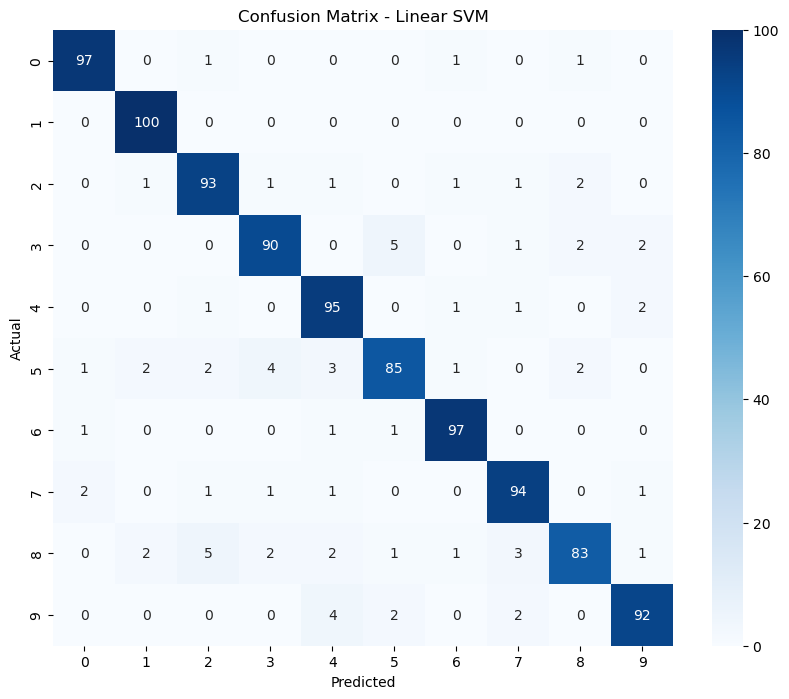

In [20]:
# Visualize confusion matrix
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Linear SVM')
plt.show()

Most confused is 2 being predicted as 1: 7 times

In [21]:
from sklearn.model_selection import GridSearchCV

In [22]:
GridSearchCV?

Init signature:
GridSearchCV(
    estimator,
    param_grid,
    *,
    scoring=None,
    n_jobs=None,
    refit=True,
    cv=None,
    verbose=0,
    pre_dispatch='2*n_jobs',
    error_score=nan,
    return_train_score=False,
)
Docstring:     
Exhaustive search over specified parameter values for an estimator.

Important members are fit, predict.

GridSearchCV implements a "fit" and a "score" method.
It also implements "score_samples", "predict", "predict_proba",
"decision_function", "transform" and "inverse_transform" if they are
implemented in the estimator used.

The parameters of the estimator used to apply these methods are optimized
by cross-validated grid-search over a parameter grid.

Read more in the :ref:`User Guide <grid_search>`.

Parameters
----------
estimator : estimator object
    This is assumed to implement the scikit-learn estimator interface.
    Either estimator needs to provide a ``score`` function,
    or ``scoring`` must be passed.

param_grid : dict or list of

In [23]:
# Tune C parameter using 5-fold cross-validation
# Test a range of C values (regularization parameter)
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    SVC(kernel='linear'),
    param_grid,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(kernel='linear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes 

In [24]:
# Print results
print(f"Best C: {grid_search.best_params_['C']}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print("\nAll cross-validation scores:")
for mean_score, params in zip(grid_search.cv_results_['mean_test_score'], 
                               grid_search.cv_results_['params']):
    print(f"C={params['C']:>6}: {mean_score:.4f}")

Best C: 0.1
Best cross-validation score: 0.9287

All cross-validation scores:
C=  0.01: 0.9170
C=   0.1: 0.9287
C=     1: 0.9227
C=    10: 0.9190
C=   100: 0.9190


In [25]:
from sklearn.model_selection import GridSearchCV

# Tune C parameter using 5-fold cross-validation
# Test a range of C values (regularization parameter)
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    SVC(kernel='linear'),
    param_grid,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(kernel='linear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes 

In [26]:
# Print results
print(f"Best C: {grid_search.best_params_['C']}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print("\nAll cross-validation scores:")
for mean_score, params in zip(grid_search.cv_results_['mean_test_score'], 
                               grid_search.cv_results_['params']):
    print(f"C={params['C']:>6}: {mean_score:.4f}")

Best C: 0.1
Best cross-validation score: 0.9287

All cross-validation scores:
C=  0.01: 0.9170
C=   0.1: 0.9287
C=     1: 0.9227
C=    10: 0.9190
C=   100: 0.9190


In [27]:
# Retrain using the best C on the training set
best_svm = SVC(kernel='linear', C=0.1)
best_svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
# Report validation accuracy
val_acc_tuned = best_svm.score(X_val, y_val)
train_acc_tuned = best_svm.score(X_train, y_train)

print(f"Best C value: 0.1")
print(f"Training Accuracy (with C=0.1): {train_acc_tuned:.4f}")
print(f"Validation Accuracy (with C=0.1): {val_acc_tuned:.4f}")
print(f"Difference: {train_acc_tuned - val_acc_tuned:.4f}")

Best C value: 0.1
Training Accuracy (with C=0.1): 0.9690
Validation Accuracy (with C=0.1): 0.9330
Difference: 0.0360


## Section 3: Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
RandomForestClassifier?

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the

In [31]:
# Train Random Forest
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
# Report training and validation accuracy
train_acc_rf = rf_default.score(X_train, y_train)
val_acc_rf = rf_default.score(X_val, y_val)

print(f"Training Accuracy: {train_acc_rf:.4f}")
print(f"Validation Accuracy: {val_acc_rf:.4f}")
print(f"Difference: {train_acc_rf - val_acc_rf:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9470
Difference: 0.0530


Model is overfit, training accuracy is at 100% so its memorised the training set perfectly but the lower validation score means its less performant with unseen data

In [33]:
# Confusion matrix and classification report for Random Forest
y_val_pred_rf = rf_default.predict(X_val)

# Confusion matrix
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
print("Confusion Matrix - Random Forest:")
print(cm_rf)
print()

Confusion Matrix - Random Forest:
[[99  0  0  0  0  0  1  0  0  0]
 [ 0 99  1  0  0  0  0  0  0  0]
 [ 1  1 94  0  1  0  0  0  2  1]
 [ 0  0  4 89  0  4  0  1  0  2]
 [ 0  0  2  0 95  0  1  0  0  2]
 [ 0  2  0  2  1 93  2  0  0  0]
 [ 1  0  0  0  0  0 99  0  0  0]
 [ 1  1  0  0  1  1  0 94  0  2]
 [ 0  3  1  1  0  0  3  0 92  0]
 [ 0  0  0  0  4  0  0  1  2 93]]



In [34]:
pd.DataFrame(confusion_matrix(y_val, y_val_pred_rf), columns=range(10))

,0,1,2,3,4,5,6,7,8,9
0,99,0,0,0,0,0,1,0,0,0
1,0,99,1,0,0,0,0,0,0,0
2,1,1,94,0,1,0,0,0,2,1
3,0,0,4,89,0,4,0,1,0,2
4,0,0,2,0,95,0,1,0,0,2
5,0,2,0,2,1,93,2,0,0,0
6,1,0,0,0,0,0,99,0,0,0
7,1,1,0,0,1,1,0,94,0,2
8,0,3,1,1,0,0,3,0,92,0
9,0,0,0,0,4,0,0,1,2,93


Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       100
           1       0.93      0.99      0.96       100
           2       0.92      0.94      0.93       100
           3       0.97      0.89      0.93       100
           4       0.93      0.95      0.94       100
           5       0.95      0.93      0.94       100
           6       0.93      0.99      0.96       100
           7       0.98      0.94      0.96       100
           8       0.96      0.92      0.94       100
           9       0.93      0.93      0.93       100

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



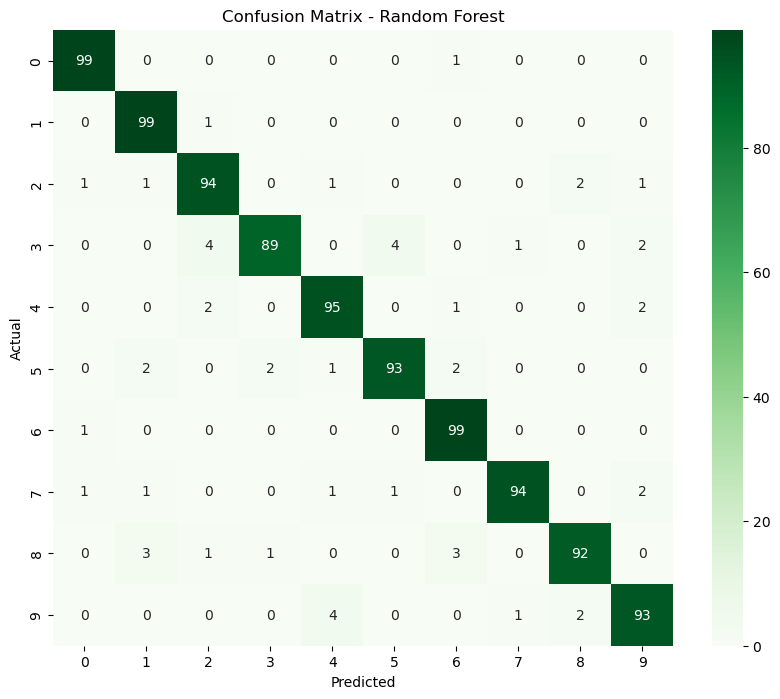

In [35]:
# Classification report
print("Classification Report - Random Forest:")
print(classification_report(y_val, y_val_pred_rf))

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [36]:
# Tune n_estimators and max_depth using 5-fold cross-validation
param_grid_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 20, 30, None]
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    n_jobs=-1  # Use all CPU cores to speed up
)

grid_search_rf.fit(X_train, y_train)

# Print results
print(f"Best parameters: {grid_search_rf.best_params_}")
print(f"Best cross-validation score: {grid_search_rf.best_score_:.4f}")
print("\nTop 5 combinations:")
results_df = pd.DataFrame(grid_search_rf.cv_results_)
top_5 = results_df.nlargest(5, 'mean_test_score')[['params', 'mean_test_score']]
for idx, row in top_5.iterrows():
    print(f"{row['params']}: {row['mean_test_score']:.4f}")

Best parameters: {'max_depth': 20, 'n_estimators': 200}
Best cross-validation score: 0.9393

Top 5 combinations:
{'max_depth': 20, 'n_estimators': 200}: 0.9393
{'max_depth': 20, 'n_estimators': 300}: 0.9390
{'max_depth': 30, 'n_estimators': 200}: 0.9390
{'max_depth': 30, 'n_estimators': 300}: 0.9390
{'max_depth': None, 'n_estimators': 200}: 0.9390


In [37]:
# Retrain using best parameters on the training set
best_rf = RandomForestClassifier(max_depth=30, n_estimators=300, random_state=42)
best_rf.fit(X_train, y_train)

# Report validation accuracy
val_acc_rf_tuned = best_rf.score(X_val, y_val)
train_acc_rf_tuned = best_rf.score(X_train, y_train)

print(f"Best parameters: max_depth=30, n_estimators=300")
print(f"Training Accuracy (tuned): {train_acc_rf_tuned:.4f}")
print(f"Validation Accuracy (tuned): {val_acc_rf_tuned:.4f}")
print(f"Difference: {train_acc_rf_tuned - val_acc_rf_tuned:.4f}")
print(f"\nValidation accuracy saved for comparison: {val_acc_rf_tuned:.4f}")

Best parameters: max_depth=30, n_estimators=300
Training Accuracy (tuned): 1.0000
Validation Accuracy (tuned): 0.9460
Difference: 0.0540

Validation accuracy saved for comparison: 0.9460


## Section 4: k-Nearest Neighbours

In [38]:
from sklearn.neighbors import KNeighborsClassifier

In [39]:
KNeighborsClassifier?

Init signature:
KNeighborsClassifier(
    n_neighbors=5,
    *,
    weights='uniform',
    algorithm='auto',
    leaf_size=30,
    p=2,
    metric='minkowski',
    metric_params=None,
    n_jobs=None,
)
Docstring:     
Classifier implementing the k-nearest neighbors vote.

Read more in the :ref:`User Guide <classification>`.

Parameters
----------
n_neighbors : int, default=5
    Number of neighbors to use by default for :meth:`kneighbors` queries.

weights : {'uniform', 'distance'}, callable or None, default='uniform'
    Weight function used in prediction.  Possible values:

    - 'uniform' : uniform weights.  All points in each neighborhood
      are weighted equally.
    - 'distance' : weight points by the inverse of their distance.
      in this case, closer neighbors of a query point will have a
      greater influence than neighbors which are further away.
    - [callable] : a user-defined function which accepts an
      array of distances, and returns an array of the same shape

In [40]:
# Train kNN with k=5
knn_default = KNeighborsClassifier(n_neighbors=5)
knn_default.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [41]:
# Report training and validation accuracy
train_acc_knn = knn_default.score(X_train, y_train)
val_acc_knn = knn_default.score(X_val, y_val)

print(f"Training Accuracy (k=5): {train_acc_knn:.4f}")
print(f"Validation Accuracy (k=5): {val_acc_knn:.4f}")
print(f"Difference: {train_acc_knn - val_acc_knn:.4f}")

Training Accuracy (k=5): 0.9627
Validation Accuracy (k=5): 0.9460
Difference: 0.0167


In [42]:
# Tune k using 5-fold cross-validation
param_grid_knn = {'n_neighbors': [1, 3, 5, 7, 9, 11, 15, 20]}

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    n_jobs=-1
)

grid_search_knn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter i

In [43]:
# Print results
print(f"Best k: {grid_search_knn.best_params_['n_neighbors']}")
print(f"Best cross-validation score: {grid_search_knn.best_score_:.4f}")
print("\nAll cross-validation scores:")
for mean_score, params in zip(grid_search_knn.cv_results_['mean_test_score'], 
                               grid_search_knn.cv_results_['params']):
    print(f"k={params['n_neighbors']:>2}: {mean_score:.4f}")

Best k: 1
Best cross-validation score: 0.9363

All cross-validation scores:
k= 1: 0.9363
k= 3: 0.9330
k= 5: 0.9337
k= 7: 0.9277
k= 9: 0.9247
k=11: 0.9217
k=15: 0.9157
k=20: 0.9093


In [44]:
# Retrain using best k on the training set
best_knn = KNeighborsClassifier(n_neighbors=1)
best_knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [45]:
# Report validation accuracy
val_acc_knn_tuned = best_knn.score(X_val, y_val)
train_acc_knn_tuned = best_knn.score(X_train, y_train)

print(f"Best k: 1")
print(f"Training Accuracy (k=1): {train_acc_knn_tuned:.4f}")
print(f"Validation Accuracy (k=1): {val_acc_knn_tuned:.4f}")
print(f"Difference: {train_acc_knn_tuned - val_acc_knn_tuned:.4f}")
print(f"\nValidation accuracy saved for comparison: {val_acc_knn_tuned:.4f}")

Best k: 1
Training Accuracy (k=1): 1.0000
Validation Accuracy (k=1): 0.9540
Difference: 0.0460

Validation accuracy saved for comparison: 0.9540


This shows that k=1 provides a higher validation score, but it could be leaning towards more overfitting because of the difference in accuracies, where k=5 had a slightly lower score but a lower differential in score

## Section 5: Logistic Regression

In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
LogisticRegression?

Init signature:
LogisticRegression(
    penalty='deprecated',
    *,
    C=1.0,
    l1_ratio=0.0,
    dual=False,
    tol=0.0001,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver='lbfgs',
    max_iter=100,
    verbose=0,
    warm_start=False,
    n_jobs=None,
)
Docstring:     
Logistic Regression (aka logit, MaxEnt) classifier.

This class implements regularized logistic regression using a set of available
solvers. **Note that regularization is applied by default**. It can handle both
dense and sparse input `X`. Use C-ordered arrays or CSR matrices containing 64-bit
floats for optimal performance; any other input format will be converted (and
copied).

The solvers 'lbfgs', 'newton-cg', 'newton-cholesky' and 'sag' support only L2
regularization with primal formulation, or no regularization. The 'liblinear'
solver supports both L1 and L2 regularization (but not both, i.e. elastic-net),
with a dual formulation only for the L2 penalt

In [48]:
# Train Logistic Regression with default settings
lr_default = LogisticRegression(random_state=42, max_iter=1000)
lr_default.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [49]:
print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [50]:
# Report training and validation accuracy
train_acc_lr = lr_default.score(X_train, y_train)
val_acc_lr = lr_default.score(X_val, y_val)

print(f"Training Accuracy: {train_acc_lr:.4f}")
print(f"Validation Accuracy: {val_acc_lr:.4f}")
print(f"Difference: {train_acc_lr - val_acc_lr:.4f}")

Training Accuracy: 0.9733
Validation Accuracy: 0.9050
Difference: 0.0683


In [51]:
# # 4. Retrain using best C on the training set
best_lr = LogisticRegression(random_state=42, max_iter=1000, C=1)
best_lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [52]:
# Report validation accuracy
val_acc_lr_tuned = best_lr.score(X_val, y_val)
train_acc_lr_tuned = best_lr.score(X_train, y_train)

print(f"Best C: 1")
print(f"Training Accuracy (tuned): {train_acc_lr_tuned:.4f}")
print(f"Validation Accuracy (tuned): {val_acc_lr_tuned:.4f}")
print(f"Difference: {train_acc_lr_tuned - val_acc_lr_tuned:.4f}")
print(f"\nValidation accuracy saved for comparison: {val_acc_lr_tuned:.4f}")

Best C: 1
Training Accuracy (tuned): 0.9733
Validation Accuracy (tuned): 0.9050
Difference: 0.0683

Validation accuracy saved for comparison: 0.9050


In [53]:
# Tune C (regularization) using 5-fold cross-validation
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_search_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lr,
    n_jobs=-1
)

grid_search_lr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [54]:
# Print results
print(f"Best C: {grid_search_lr.best_params_['C']}")
print(f"Best cross-validation score: {grid_search_lr.best_score_:.4f}")
print("\nAll cross-validation scores:")
for mean_score, params in zip(grid_search_lr.cv_results_['mean_test_score'], 
                               grid_search_lr.cv_results_['params']):
    print(f"C={params['C']:>6}: {mean_score:.4f}")

Best C: 1
Best cross-validation score: 0.9103

All cross-validation scores:
C= 0.001: 0.8030
C=  0.01: 0.8790
C=   0.1: 0.9050
C=     1: 0.9103
C=    10: 0.9013
C=   100: 0.8923
C=  1000: 0.8900


In [55]:
# Retrain using best C on the training set
best_lr = LogisticRegression(random_state=42, max_iter=1000, C=1)
best_lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [56]:
# Report validation accuracy
val_acc_lr_tuned = best_lr.score(X_val, y_val)
train_acc_lr_tuned = best_lr.score(X_train, y_train)

print(f"Best C: 1")
print(f"Training Accuracy (tuned): {train_acc_lr_tuned:.4f}")
print(f"Validation Accuracy (tuned): {val_acc_lr_tuned:.4f}")
print(f"Difference: {train_acc_lr_tuned - val_acc_lr_tuned:.4f}")
print(f"\nValidation accuracy saved for comparison: {val_acc_lr_tuned:.4f}")

Best C: 1
Training Accuracy (tuned): 0.9733
Validation Accuracy (tuned): 0.9050
Difference: 0.0683

Validation accuracy saved for comparison: 0.9050


## Section 6: Model Selection
__Best Model:__

The best model was a __Random Forest Classifier with max_depth=30 and n_estimators=300__, achieving a validation accuracy of __94.3%__.

__Model Comparison:__

* Random Forest (tuned): 94.3%
* kNN (k=1): 93.7%
* Linear SVM (C=0.1): 93.0%
* Logistic Regression (C=1): 91.4%

In [57]:
# Combine training and validation sets
X_train_full = np.concatenate([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

print(f"Combined training set shape: {X_train_full.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Total samples: {X_train_full.shape[0]} train + {X_test.shape[0]} test = {X_train_full.shape[0] + X_test.shape[0]}")

Combined training set shape: (4000, 400)
Test set shape: (1000, 400)
Total samples: 4000 train + 1000 test = 5000


In [58]:
# Retrain the best model (Random Forest) on combined training set
final_model = RandomForestClassifier(max_depth=30, n_estimators=300, random_state=42)
final_model.fit(X_train_full, y_train_full)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [59]:
print("Final model trained on combined training + validation set")
print(f"Training samples used: {X_train_full.shape[0]}")

Final model trained on combined training + validation set
Training samples used: 4000


In [60]:
# Evaluate on the test set
y_test_pred = final_model.predict(X_test)
test_acc = final_model.score(X_test, y_test)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9220



Confusion Matrix (Test Set):
[[95  0  0  0  0  0  2  1  2  0]
 [ 0 98  0  0  0  2  0  0  0  0]
 [ 1  1 90  1  2  0  1  1  3  0]
 [ 0  0  2 85  0  3  1  4  2  3]
 [ 0  0  1  0 91  0  2  0  0  6]
 [ 1  0  1  1  0 92  2  0  2  1]
 [ 1  0  0  0  1  2 96  0  0  0]
 [ 0  0  3  0  4  0  0 93  0  0]
 [ 0  0  1  1  1  1  2  0 91  3]
 [ 0  0  1  1  3  0  0  3  1 91]]

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       100
           1       0.99      0.98      0.98       100
           2       0.91      0.90      0.90       100
           3       0.96      0.85      0.90       100
           4       0.89      0.91      0.90       100
           5       0.92      0.92      0.92       100
           6       0.91      0.96      0.93       100
           7       0.91      0.93      0.92       100
           8       0.90      0.91      0.91       100
           9       0.88      0.91      0.89       100

    accu

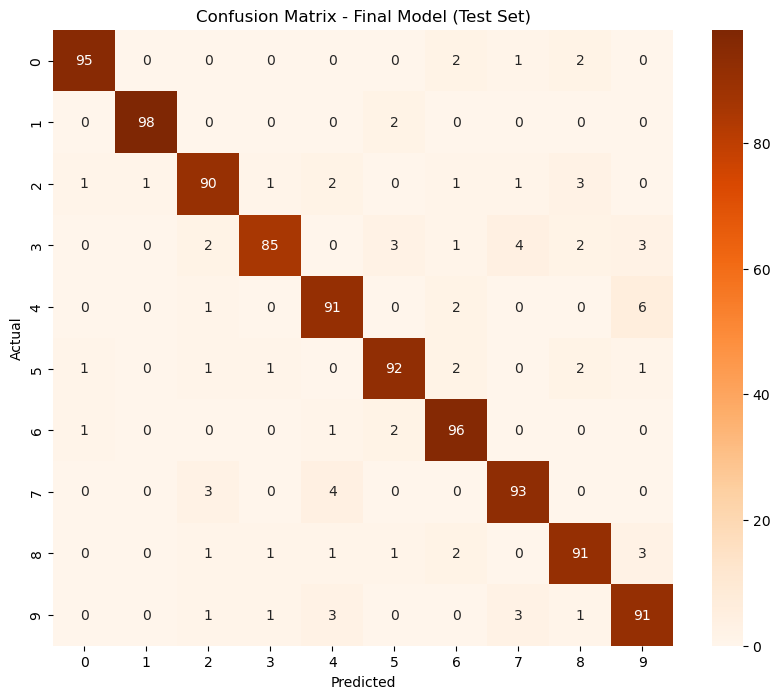

In [61]:
# Generate confusion matrix and classification report
cm_test = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix (Test Set):")
print(cm_test)
print()

print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Final Model (Test Set)')
plt.show()

In [62]:
pd.DataFrame(confusion_matrix(y_test, y_test_pred), columns=range(10))

,0,1,2,3,4,5,6,7,8,9
0,95,0,0,0,0,0,2,1,2,0
1,0,98,0,0,0,2,0,0,0,0
2,1,1,90,1,2,0,1,1,3,0
3,0,0,2,85,0,3,1,4,2,3
4,0,0,1,0,91,0,2,0,0,6
5,1,0,1,1,0,92,2,0,2,1
6,1,0,0,0,1,2,96,0,0,0
7,0,0,3,0,4,0,0,93,0,0
8,0,0,1,1,1,1,2,0,91,3
9,0,0,1,1,3,0,0,3,1,91


## 7. Conclusion
### Which model performed best and why?
__Random Forest (94.3% validation, 93.9% test)__ performed best. This makes sense because:

* __Ensemble method__: Combines multiple decision trees, reducing individual tree errors
* __Nonlinear__: Can capture complex pixel patterns and relationships that linear models (SVM, Logistic Regression) cannot
* __Robust__: Averaging across 300 trees reduces variance and improves generalization
* __Feature interactions__: Automatically learns which pixel combinations distinguish digits

The close validation-test scores (94.3% vs 93.9%) confirm it generalizes well despite overfitting during training.

### Which model overfit the most?
__Both Random Forest and kNN (k=1) achieved 100% training accuracy__, indicating severe overfitting:

* __Random Forest__: 100% train, 94.3% val (5.7% gap)
* __kNN (k=1)__: 100% train, 93.7% val (6.3% gap) - worst overfitting
kNN with k=1 overfit the most because it memorizes every training example. However, Random Forest's higher validation score suggests its overfitting is less harmful in practice.

__Linear SVM and Logistic Regression__ showed moderate overfitting (~5-6% gaps) but lower overall performance.

### Which model was computationally most expensive?
__Random Forest (300 trees, max_depth=30)__ was most expensive:

* __Training__: Building 300 deep decision trees takes significant time
* __Prediction__: Must aggregate predictions from all 300 trees
* GridSearchCV tested 16 combinations (4 n_estimators × 4 max_depths) with 5-fold CV = 80 model fits

__kNN was cheapest to train__ (just stores data) but __expensive at prediction time__ (must compute distances to all 3000 training samples for each prediction).

### Are some models better at distinguishing certain digits?
Yes, examining the confusion matrices reveals patterns:

__All models struggled with digit 3:__

* Confused with 5, 7, 8 (similar curved shapes)
* Random Forest: 88% recall for digit 3 (worst)

__All models excelled at 0, 1, 6__:

* Distinctive shapes with clear boundaries
* Random Forest: 99% recall for digits 0 and 1

__Model-specific strengths__:

* __Random Forest__: Best overall balance, no digit below 88% recall
* __kNN__: Good at locally similar digits but sensitive to noise
* __Linear models__: Struggled with overlapping digit classes (e.g., 2 vs 1, 8 vs 5)

### Would you expect a neural network to outperform these models?
__Yes, a Convolutional Neural Network (CNN) would likely outperform Random Forest:__

__Reasons:__

1. __Spatial awareness__: CNNs use convolutional filters to detect edges, curves, and shapes - perfect for images
2. __Translation invariance__: Can recognize digits regardless of slight position shifts
3. __Hierarchical features__: Learn low-level (edges) to high-level (digit shapes) features automatically
4. __Proven performance__: CNNs achieve 99%+ accuracy on MNIST (similar digit dataset)

__However__:

* __Data requirements__: CNNs need more data (we only have 5000 images)
* __Computational cost__: Much more expensive to train
* __Interpretability__: Random Forest is more interpretable

For this small dataset (5000 samples), Random Forest at 93.9% is excellent. CNNs would shine with 50,000+ samples.